In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [2]:
def calculate_depreciation(purchase_price, tire_cost, life_years,
                           method="straight_line", residual=42000, rate=0.144):
    if method == "straight_line":
        # Subtracting tires for precision in constant depreciation
        depreciable_base = purchase_price - (tire_cost + residual)
        annual_depreciation = depreciable_base / life_years
        written_down = [] #vehicle written down value after each year
        written_past = purchase_price - tire_cost #initial vehicle value
        for year in range(life_years):
            written_current = written_past - annual_depreciation
            written_down.append(written_current)
            written_past = written_current
        return ([annual_depreciation] * life_years, written_down)
    
    elif method == "declining_balance":
        # Usually calculated on the full initial cost
        schedule = []
        written_down = []
        written_past = purchase_price
        book_value = purchase_price
        for year in range(life_years):
            depreciation = book_value * rate
            schedule.append(round(depreciation, 0))
            book_value -= depreciation
            written_down.append(round(book_value, 0))
        return (schedule, written_down)

line = calculate_depreciation(125000, 7134, 7, "straight_line")
print(f"The constant depreciation is: {line}")

balance = calculate_depreciation(125000, 7134, 7, "declining_balance", 0.144)
print(f"The declining balance depreciation is: {balance}")

The constant depreciation is: ([10838.0, 10838.0, 10838.0, 10838.0, 10838.0, 10838.0, 10838.0], [107028.0, 96190.0, 85352.0, 74514.0, 63676.0, 52838.0, 42000.0])
The declining balance depreciation is: ([18000.0, 15408.0, 13189.0, 11290.0, 9664.0, 8273.0, 7081.0], [107000.0, 91592.0, 78403.0, 67113.0, 57449.0, 49176.0, 42095.0])


In [3]:
years = [1, 2, 3, 4, 5, 6, 7]

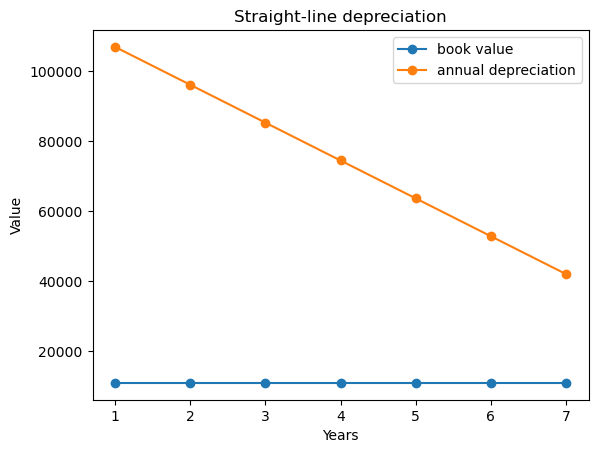

In [4]:
plt.plot(years, line[0], linestyle='-', marker='o', label='book value')
plt.plot(years, line[1], linestyle='-', marker='o', label='annual depreciation')
plt.title("Straight-line depreciation")
plt.xlabel("Years")
plt.ylabel("Value")
plt.legend()

plt.show()

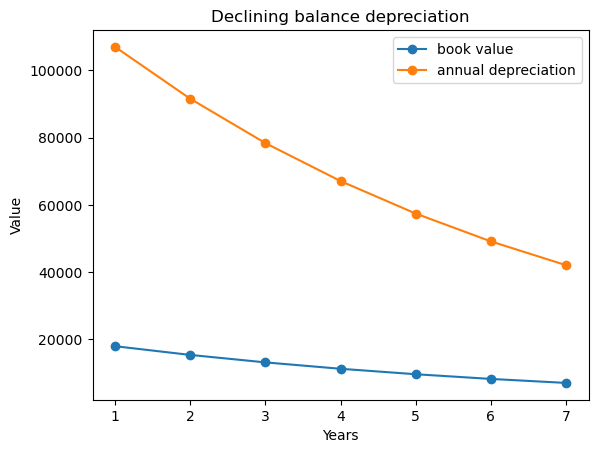

In [5]:
plt.plot(years, balance[0], linestyle='-', marker='o', label='book value')
plt.plot(years, balance[1], linestyle='-', marker='o', label='annual depreciation')
plt.title("Declining balance depreciation")
plt.xlabel("Years")
plt.ylabel("Value")
plt.legend()

plt.show()